#  DropAlert: Pengembangan Sistem Deteksi Dini Risiko Putus Sekolah Menggunakan Ensemble Learning Berbasis Dashboard Interaktif untuk Mendukung Intervensi Pendidikan di Era Society 5.0

## **Dataset Gabungan (buat analisis prediksi)**

###VARIABEL X

1. Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah (Persen)
- kota_pendudukmiskin
- desa_pendudukmiskin
- gabungan_pendudukmiskin

2. Tingkat Pengangguran Terbuka Menurut Provinsi (Persen)
- TPT

3. Persentase Usia Muda (15-24 Tahun) Yang Sedang Tidak Sekolah, Bekerja Atau Mengikuti Pelatihan (Persen)
- NEET_usiamuda

4. Persentase Tenaga Kerja Formal Menurut Provinsi (Persen)
- tenagakerjaformal

5. Jumlah Satuan Pendidikan, Kepala Sekolah dan Guru, serta Peserta Didik1 Sekolah Menengah Atas (SMA) di Bawah Kementerian Pendidikan Dasar dan Menengah Menurut Provinsi
- SMA_negeri_jumlahsekolah
- SMA_swasta_jumlahsekolah
- SMA_negeri_jumlahguru
- SMA_swasta_jumlahguru
- SMA_negeri_jumlahmurid
- SMA_swasta_jumlahmurid
- SMA_gabungan_jumlahsekolah
- SMA_gabungan_jumlahguru
- SMA_gabungan_jumlahmurid

6. Jumlah Satuan Pendidikan, Kepala Sekolah dan Guru, serta Peserta Didik1 Sekolah Menengah Kejuruan (SMK) di Bawah Kementerian Pendidikan Dasar dan Menengah Menurut Provinsi
- SMK_negeri_jumlahsekolah
- SMK_swasta_jumlahsekolah
- SMK_negeri_jumlahguru
- SMK_swasta_jumlahguru
- SMK_negeri_jumlahmurid
- SMK_swasta_jumlahmurid
- SMK_gabungan_jumlahsekolah
- SMK_gabungan_jumlahguru
- SMK_gabungan_jumlahmurid

7. Angka Harapan Lama Sekolah (HLS) menurut Jenis Kelamin (Tahun)
- laki_HLS
- perempuan_HLS
- gabungan_HLS

8. Rata-rata Lama Sekolah (RLS) menurut Jenis Kelamin (Tahun)
- laki_RLS
- perempuan_RLS
- gabungan_RLS

9. Jumlah Satuan Pendidikan, Kepala Sekolah dan Guru, serta Peserta Didik1 Sekolah Dasar (SD) di Bawah Kementerian Pendidikan Dasar dan Menengah Menurut Provinsi
- SD_negeri_jumlahsekolah
- SD_swasta_jumlahsekolah
- SD_negeri_jumlahguru
- SD_swasta_jumlahguru
- SD_negeri_jumlahmurid
- SD_swasta_jumlahmurid
- SD_gabungan_jumlahsekolah
- SD_gabungan_jumlahguru
- SD_gabungan_jumlahmurid

10. Jumlah Satuan Pendidikan, Kepala Sekolah dan Guru, serta Peserta Didik1 Sekolah Menengah Pertama (SMP) di Bawah Kementerian Pendidikan Dasar dan Menengah Menurut Provinsi
- SMP_negeri_jumlahsekolah
- SMP_swasta_jumlahsekolah
- SMP_negeri_jumlahguru
- SMP_swasta_jumlahguru
- SMP_negeri_jumlahmurid
- SMP_swasta_jumlahmurid
- SMP_gabungan_jumlahsekolah
- SMP_gabungan_jumlahguru
- SMP_gabungan_jumlahmurid


### VARIABEL Y
11. Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur
- APS_07to12	(umur 7 hingga 12 tahun)
- APS_13to15	(umur 13 hingga 15 tahun)
- APS_16to18	(umur 16 hingga 18 tahun)
- APS_19to23(umur 19 hingga 23 tahun)

## **Dataset Lain (buat grafik/visual jika diperlukan)**

1. Percentage of Poor People (P0) by Area
2. Tingkat Pengangguran Terbuka Berdasarkan Tingkat Pendidikan
3. Pengangguran Menurut Golongan Umur (Orang)


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

df = pd.read_excel('Dataset_Gabungan_Fix.xlsx')
df

,Provinsi,Tahun,kota_pendudukmiskin,desa_pendudukmiskin,gabungan_pendudukmiskin,NEET_usiamuda,tenagakerjaformal,SMA_negeri_jumlahsekolah,SMA_swasta_jumlahsekolah,SMA_negeri_jumlahguru,...,SD_gabungan_jumlahmurid,SMP_negeri_jumlahsekolah,SMP_swasta_jumlahsekolah,SMP_gabungan_jumlahsekolah,SMP_negeri_jumlahguru,SMP_swasta_jumlahguru,SMP_gabungan_jumlahguru,SMP_negeri_jumlahmurid,SMP_swasta_jumlahmurid,SMP_gabungan_jumlahmurid
0,ACEH,2021,10.520,17.910,15.430,24.38,39.31,395.0,134.0,11995.0,...,488831.0,897.0,316.0,1213.0,20137.0,3431.0,23568.0,160011.0,44534.0,204545.0
1,SUMATERA UTARA,2021,8.915,8.550,8.750,20.29,40.67,427.0,639.0,15064.0,...,1587108.0,1331.0,1315.0,2646.0,31669.0,13699.0,45368.0,433519.0,221370.0,654889.0
2,SUMATERA BARAT,2021,5.065,7.570,6.335,18.78,35.23,236.0,95.0,9829.0,...,608926.0,674.0,171.0,845.0,15956.0,2204.0,18160.0,184026.0,23579.0,207605.0
3,RIAU,2021,6.620,7.350,7.060,21.11,45.43,303.0,144.0,9650.0,...,777851.0,855.0,375.0,1230.0,16013.0,4390.0,20403.0,206252.0,54858.0,261110.0
4,JAMBI,2021,11.010,6.350,7.880,21.76,37.99,161.0,74.0,5121.0,...,371924.0,557.0,136.0,693.0,10192.0,1360.0,11552.0,102206.0,20213.0,122419.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,PAPUA,2025,6.215,38.235,18.490,26.34,47.12,65.0,54.0,1612.0,...,117710.0,195.0,88.0,283.0,3096.0,866.0,3962.0,39328.0,12537.0,51865.0
191,PAPUA SELATAN,2025,4.525,28.325,19.485,21.95,34.12,25.0,15.0,714.0,...,96008.0,99.0,38.0,137.0,1652.0,429.0,2081.0,22093.0,7200.0,29293.0
192,PAPUA TENGAH,2025,6.025,37.840,29.175,21.18,15.28,31.0,29.0,792.0,...,145970.0,102.0,71.0,173.0,1783.0,755.0,2538.0,28168.0,14145.0,42313.0
193,PAPUA PEGUNUNGAN,2025,13.030,30.805,28.620,11.62,4.70,50.0,22.0,658.0,...,143990.0,160.0,55.0,215.0,1698.0,383.0,2081.0,34149.0,9763.0,43912.0


In [3]:
print("Struktur Data:")
print(df.info())

print("\nStatistik Deskriptif:")
display(df.describe())

Struktur Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Provinsi                    195 non-null    object 
 1   Tahun                       195 non-null    int64  
 2   kota_pendudukmiskin         195 non-null    float64
 3   desa_pendudukmiskin         195 non-null    float64
 4   gabungan_pendudukmiskin     195 non-null    float64
 5   NEET_usiamuda               195 non-null    float64
 6   tenagakerjaformal           195 non-null    float64
 7   SMA_negeri_jumlahsekolah    195 non-null    float64
 8   SMA_swasta_jumlahsekolah    195 non-null    float64
 9   SMA_negeri_jumlahguru       195 non-null    float64
 10  SMA_swasta_jumlahguru       195 non-null    float64
 11  SMA_negeri_jumlahmurid      195 non-null    float64
 12  SMA_swasta_jumlahmurid      195 non-null    float64
 13  SMA_gabungan_jumlahs

,Tahun,kota_pendudukmiskin,desa_pendudukmiskin,gabungan_pendudukmiskin,NEET_usiamuda,tenagakerjaformal,SMA_negeri_jumlahsekolah,SMA_swasta_jumlahsekolah,SMA_negeri_jumlahguru,SMA_swasta_jumlahguru,...,SD_gabungan_jumlahmurid,SMP_negeri_jumlahsekolah,SMP_swasta_jumlahsekolah,SMP_gabungan_jumlahsekolah,SMP_negeri_jumlahguru,SMP_swasta_jumlahguru,SMP_gabungan_jumlahguru,SMP_negeri_jumlahmurid,SMP_swasta_jumlahmurid,SMP_gabungan_jumlahmurid
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,1.950000e+02,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,1.950000e+02,1.950000e+02,1.950000e+02
mean,2023.000000,6.548282,12.055103,9.702897,20.256000,37.946205,361.784615,378.328205,12959.958974,5008.307692,...,1.235258e+06,1229.538462,950.646154,2180.184615,26702.358974,9916.574359,36618.933333,3.742825e+05,1.403384e+05,5.146210e+05
std,1.417854,3.041480,6.830157,4.898386,6.191455,13.531821,1096.548116,1170.376113,39455.901292,15534.498043,...,3.813458e+06,3731.353215,2975.439579,6675.762085,81423.906385,31049.720332,112188.507590,1.152455e+06,4.416966e+05,1.591982e+06
min,2021.000000,1.231250,4.155000,3.570000,4.627500,3.892500,22.000000,8.000000,603.000000,69.000000,...,6.022700e+04,94.000000,26.000000,130.000000,1592.000000,226.000000,2004.000000,1.785600e+04,2.321000e+03,2.465000e+04
25%,2022.000000,4.440000,7.355000,6.317500,18.100000,33.930000,70.000000,39.500000,2381.000000,401.750000,...,1.463695e+05,236.500000,77.000000,383.000000,4478.500000,773.000000,5913.500000,4.951550e+04,9.532500e+03,6.003400e+04
50%,2023.000000,5.830000,10.425000,8.360000,21.170000,39.130000,150.000000,86.000000,4908.000000,1093.000000,...,3.531740e+05,552.000000,175.000000,733.000000,9446.000000,1909.000000,11434.000000,1.027920e+05,2.403500e+04,1.236290e+05
75%,2024.000000,8.640000,13.810000,11.640000,23.825000,45.795000,303.000000,262.000000,9926.000000,3143.500000,...,7.731995e+05,899.000000,465.000000,1400.500000,17350.000000,4983.000000,24152.500000,2.325695e+05,6.841400e+04,3.305560e+05
max,2025.000000,14.915000,38.235000,31.315000,35.380000,68.450000,7191.000000,7619.000000,263498.000000,102709.000000,...,2.433176e+07,24217.000000,19376.000000,43593.000000,533197.000000,203602.000000,723796.000000,7.399231e+06,2.762329e+06,1.016156e+07


# INI YANG BENAR

In [21]:
# FEATURE ENGINEERING
df_model = df.copy()
df_model = df_model[df_model['Provinsi'] != 'INDONESIA']

# ANGKA RISIKO PUTUS SEKOLAH (ARPS)
df_model['ARPS_07to12'] = (100 - df_model['APS_07to12'])
df_model['ARPS_13to15'] = (100 - df_model['APS_13to15'])
df_model['ARPS_16to18'] = (100 - df_model['APS_16to18'])
df_model['ARPS_19to23'] = (100 - df_model['APS_19to23'])

# RASIO GURU PER MURID
df_model['rasio_guru_SMA'] = (
    df_model['SMA_gabungan_jumlahguru'] /
    df_model['SMA_gabungan_jumlahmurid']
)

df_model['rasio_guru_SMK'] = (
    df_model['SMK_gabungan_jumlahguru'] /
    df_model['SMK_gabungan_jumlahmurid']
)

df_model['rasio_guru_SD'] = (
    df_model['SD_gabungan_jumlahguru'] /
    df_model['SD_gabungan_jumlahmurid']
)


df_model['rasio_guru_SMP'] = (
    df_model['SMP_gabungan_jumlahguru'] /
    df_model['SMP_gabungan_jumlahmurid']
)

# RASIO SEKOLAH PER MURID
df_model['rasio_sekolah_SMA'] = (
    df_model['SMA_gabungan_jumlahsekolah'] /
    df_model['SMA_gabungan_jumlahmurid']
)

df_model['rasio_sekolah_SMK'] = (
    df_model['SMK_gabungan_jumlahsekolah'] /
    df_model['SMK_gabungan_jumlahmurid']
)

df_model['rasio_sekolah_SD'] = (
    df_model['SD_gabungan_jumlahsekolah'] /
    df_model['SD_gabungan_jumlahmurid']
)

df_model['rasio_sekolah_SMP'] = (
    df_model['SMP_gabungan_jumlahsekolah'] /
    df_model['SMP_gabungan_jumlahmurid']
)

# FITUR
fitur = [
    'gabungan_pendudukmiskin',
    'TPT',
    'NEET_usiamuda',
    'tenagakerjaformal',

    'gabungan_HLS',
    'gabungan_RLS',

    'rasio_guru_SMA',
    'rasio_guru_SMK',
    'rasio_guru_SD',
    'rasio_guru_SMP',

    'rasio_sekolah_SMA',
    'rasio_sekolah_SMK',
    'rasio_sekolah_SD',
    'rasio_sekolah_SMP'
]

# TARGET
TARGET_1 = 'ARPS_07to12'
TARGET_2 = 'ARPS_13to15'
TARGET_3 = 'ARPS_16to18'
TARGET_4 = 'ARPS_19to23'

In [23]:
df_model = df_model[['Tahun', 'Provinsi'] + fitur + [
    TARGET_1,
    TARGET_2,
    TARGET_3,
    TARGET_4
]].copy()

# CEK DATASET FINAL
print("STRUKTUR DATA FINAL")
print(df_model.info(), '\n')

# STATISTIK DESKRIPTIF
display(df_model.describe())

STRUKTUR DATA FINAL
<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 0 to 193
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tahun                    190 non-null    int64  
 1   Provinsi                 190 non-null    object 
 2   gabungan_pendudukmiskin  190 non-null    float64
 3   TPT                      190 non-null    float64
 4   NEET_usiamuda            190 non-null    float64
 5   tenagakerjaformal        190 non-null    float64
 6   gabungan_HLS             190 non-null    float64
 7   gabungan_RLS             190 non-null    float64
 8   rasio_guru_SMA           190 non-null    float64
 9   rasio_guru_SMK           190 non-null    float64
 10  rasio_guru_SD            190 non-null    float64
 11  rasio_guru_SMP           190 non-null    float64
 12  rasio_sekolah_SMA        190 non-null    float64
 13  rasio_sekolah_SMK        190 non-null    float64
 14  rasio_sekol

,Tahun,gabungan_pendudukmiskin,TPT,NEET_usiamuda,tenagakerjaformal,gabungan_HLS,gabungan_RLS,rasio_guru_SMA,rasio_guru_SMK,rasio_guru_SD,rasio_guru_SMP,rasio_sekolah_SMA,rasio_sekolah_SMK,rasio_sekolah_SD,rasio_sekolah_SMP,ARPS_07to12,ARPS_13to15,ARPS_16to18,ARPS_19to23
count,190.00000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,2023.00000,9.716132,12.345013,20.222632,37.858579,12.274395,8.364632,0.071876,0.082946,0.073129,0.083348,0.003124,0.003477,0.006846,0.005305,7.775895,10.886263,29.221053,71.884895
std,1.41795,4.961242,3.103714,6.265121,13.698183,3.073070,2.132014,0.011608,0.020738,0.016761,0.021539,0.000748,0.001179,0.001781,0.001635,20.710806,20.178783,16.845042,9.082869
min,2021.00000,3.570000,2.767500,4.627500,3.892500,2.787500,1.680000,0.049790,0.050683,0.029208,0.046330,0.001704,0.001657,0.002926,0.002127,0.240000,0.400000,6.970000,43.310000
25%,2022.00000,6.288750,12.863125,17.965000,33.905000,12.816250,8.116250,0.064174,0.065736,0.064818,0.065479,0.002710,0.002728,0.005591,0.004094,0.472500,2.495000,20.825000,66.555000
50%,2023.00000,8.085000,13.376250,21.140000,38.705000,13.287500,8.885000,0.069972,0.082499,0.074589,0.081893,0.002975,0.003239,0.007055,0.005179,0.630000,4.090000,25.460000,71.560000
75%,2024.00000,11.760000,13.768125,23.890000,46.017500,13.731250,9.526250,0.077913,0.095181,0.085621,0.098755,0.003559,0.004046,0.008141,0.006396,1.190000,6.567500,29.172500,75.180000
max,2025.00000,31.315000,15.827500,35.380000,68.450000,15.795000,11.595000,0.105675,0.145837,0.107226,0.131228,0.005530,0.008710,0.010324,0.009131,79.142500,79.995000,84.005000,93.720000


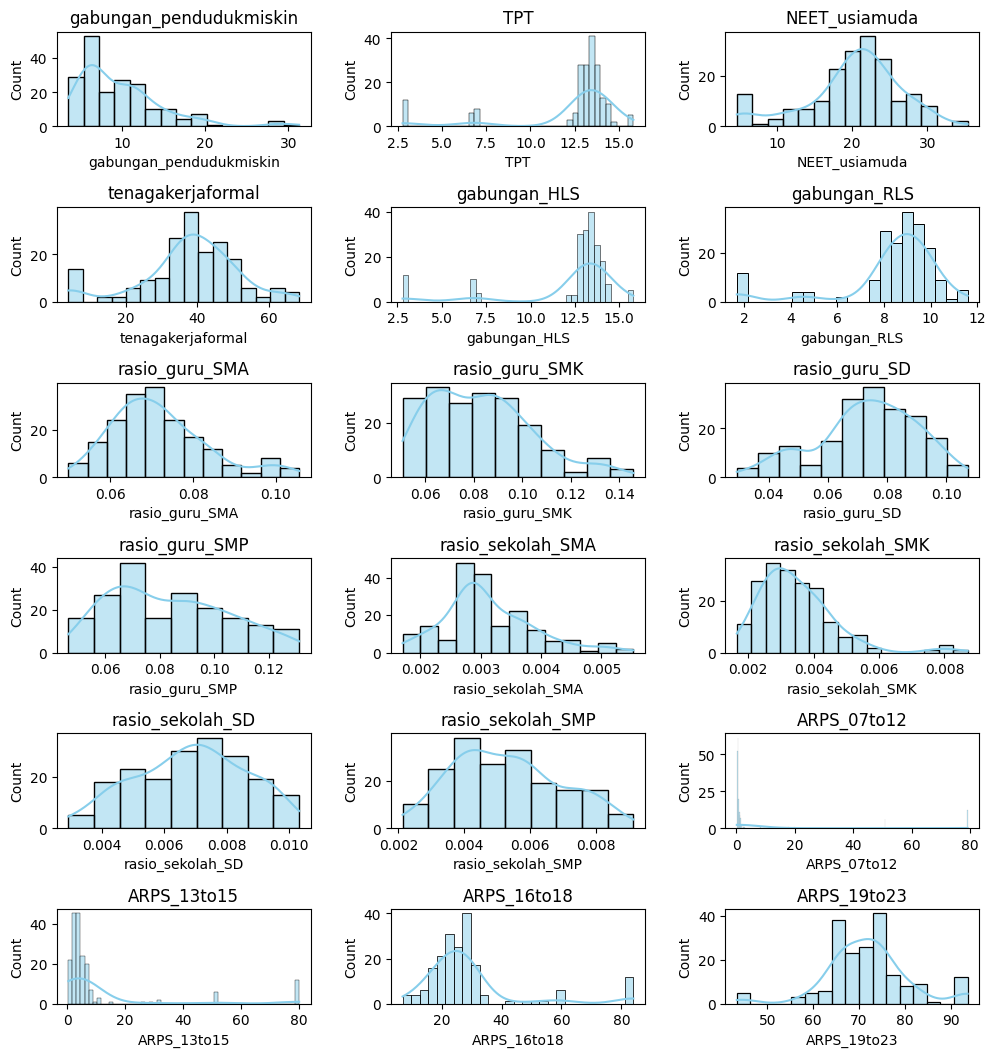

In [25]:
# DISTRIBUSI SEMUA VARIABEL NUMERIK
numeric_cols = df_model.select_dtypes(include=['float64']).columns
plt.figure(figsize=(10,12))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)//3)+1, 3, i+1)
    sns.histplot(
        df_model[col],
        kde=True,
        color='skyblue'
    )
    plt.title(col)

plt.tight_layout()
plt.show()

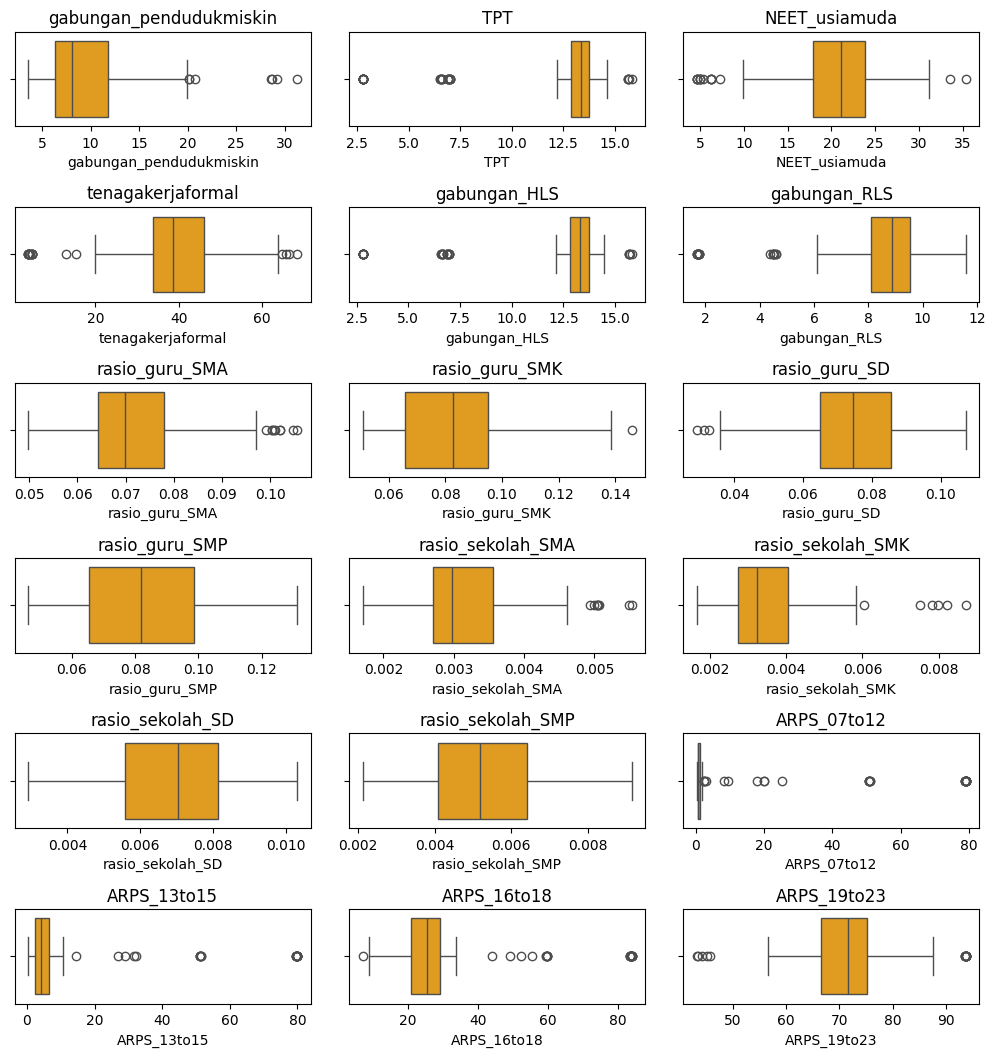

In [26]:
# BOXPLOT UNTUK DETEKSI OUTLIER
plt.figure(figsize=(10,12))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)//3)+1, 3, i+1)
    sns.boxplot(
        x=df_model[col],
        color='orange'
    )
    plt.title(col)

plt.tight_layout()
plt.show()

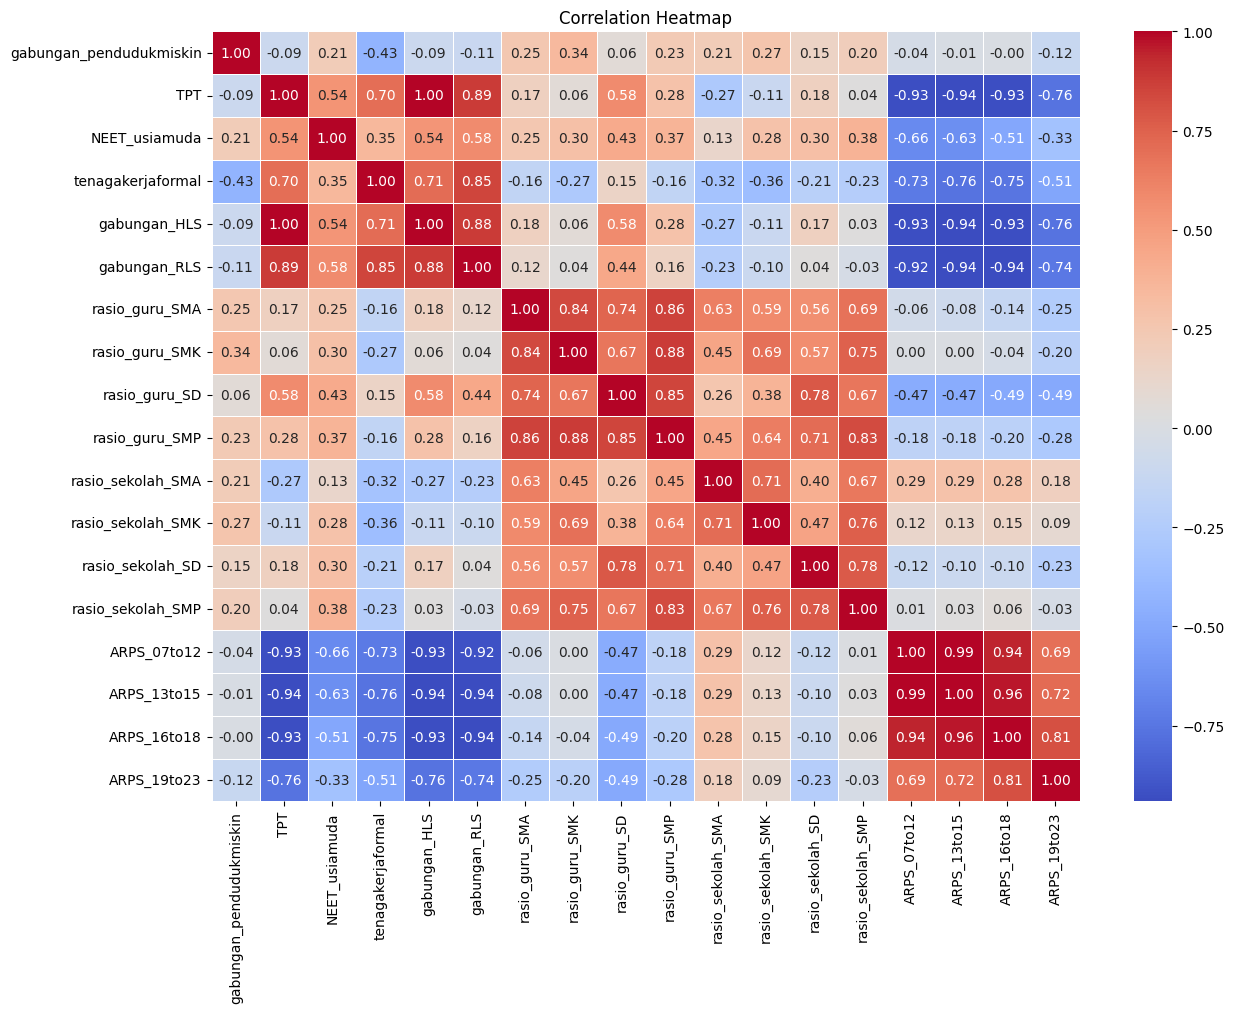

In [11]:
# hanya ambil kolom numerik
corr_matrix = df_model.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

In [15]:
print("\nKORELASI TERHADAP TARGET")

targets = [TARGET_1, TARGET_2, TARGET_3, TARGET_4]
for t in targets:
    print(f"\n--- {t} ---")
    corr_target = corr_matrix[t].sort_values(ascending=False)
    print(corr_target)


KORELASI TERHADAP TARGET

--- ARPS_07to12 ---
ARPS_07to12                1.000000
ARPS_13to15                0.994651
ARPS_16to18                0.944049
ARPS_19to23                0.690329
rasio_sekolah_SMA          0.294121
rasio_sekolah_SMK          0.122644
rasio_sekolah_SMP          0.006910
rasio_guru_SMK             0.001505
gabungan_pendudukmiskin   -0.038620
rasio_guru_SMA            -0.061423
rasio_sekolah_SD          -0.119928
rasio_guru_SMP            -0.180676
rasio_guru_SD             -0.471790
NEET_usiamuda             -0.655148
tenagakerjaformal         -0.733452
gabungan_RLS              -0.915889
gabungan_HLS              -0.926927
TPT                       -0.927724
Name: ARPS_07to12, dtype: float64

--- ARPS_13to15 ---
ARPS_13to15                1.000000
ARPS_07to12                0.994651
ARPS_16to18                0.962735
ARPS_19to23                0.715766
rasio_sekolah_SMA          0.286706
rasio_sekolah_SMK          0.134369
rasio_sekolah_SMP          0.02991

In [41]:
# FUNCTION EVALUATION - Refreshed to ensure latest df_model is used
def evaluate_model(name, target_name,
                   y_train, y_test,
                   pred_train, pred_test):

    print(f"\n{' '*50}")
    print(f"TARGET : {target_name}")
    print(f"MODEL  : {name}")

    r2_train = r2_score(y_train, pred_train)
    r2_test = r2_score(y_test, pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    mae = mean_absolute_error(y_test, pred_test)

    print("R2 Train :", round(r2_train, 4))
    print("R2 Test  :", round(r2_test, 4))
    print("RMSE     :", round(rmse, 4))
    print("MAE      :", round(mae, 4))

    # diagnosis sederhana
    gap = r2_train - r2_test

    if gap > 0.20:
        print("KESIMPULAN : OVERFITTING")

    elif r2_test < 0.5:
        print("KESIMPULAN : UNDERFITTING")

    else:
        print("KESIMPULAN : MODEL STABIL")

def run_pipeline(train_end_year):

    print(f"\nTRAIN : 2021-{train_end_year}")
    print(f"TEST  : {train_end_year+1}-2025")

    df_sorted = df_model.sort_values(
        ['Tahun', 'Provinsi']
    )

    # SPLIT TIME SERIES
    train = df_sorted[
        df_sorted['Tahun'] <= train_end_year
    ]

    test = df_sorted[
        df_sorted['Tahun'] > train_end_year
    ]

    # X DAN y
    X_train = train[fitur]
    X_test = test[fitur]

    y_train1 = train[TARGET_1]
    y_train2 = train[TARGET_2]
    y_train3 = train[TARGET_3]
    y_train4 = train[TARGET_4]

    y_test1 = test[TARGET_1]
    y_test2 = test[TARGET_2]
    y_test3 = test[TARGET_3]
    y_test4 = test[TARGET_4]

    # TARGET DICTIONARY
    targets_train = {
        'ARPS_07to12': y_train1,
        'ARPS_13to15': y_train2,
        'ARPS_16to18': y_train3,
        'ARPS_19to23': y_train4
    }

    targets_test = {
        'ARPS_07to12': y_test1,
        'ARPS_13to15': y_test2,
        'ARPS_16to18': y_test3,
        'ARPS_19to23': y_test4
    }

    # SCALING
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # MODEL
    models = {

        # LINEAR REGRESSION
        'Linear Regression': LinearRegression(
            # model linear dasar tanpa regularisasi
            # cocok sebagai baseline pembanding
        ),

        # RIDGE
        'Ridge Regression': Ridge(
            alpha=3.0, # regularisasi L2 diperbesar agar koefisien tidak terlalu besar -> mengurangi overfitting
            random_state=42
        ),

        # LASSO: regularisasi L1 untuk seleksi fitur otomatis
        'Lasso Regression': Lasso(
            alpha=0.05,       # regularisasi L1 diperbesar agar fitur  kurang penting ditekan mendekati nol -> model lebih sederhana dan stabil
            max_iter=10000,   # iterasi diperbesar agar convergence warning hilang
            random_state=42
        ),

        # ELASTIC NET: kombinasi L1 + L2
        'ElasticNet': ElasticNet(
            alpha=0.05,       # regularisasi diperkuat agar tidak overfit
            l1_ratio=0.7,     # lebih condong ke Lasso
            max_iter=10000,   # menghindari gagal konvergen
            random_state=42
        ),

        # DECISION TREE: depth dibatasi agar tidak menghafal data
        'Decision Tree': DecisionTreeRegressor(
            max_depth=3,           # pohon lebih sederhana
            min_samples_split=12,  # split lebih konservatif
            min_samples_leaf=6,    # prediksi lebih stabil
            max_features='sqrt',   # kurangi kompleksitas
            random_state=42
        ),

        # RANDOM FOREST: ensemble tree dengan generalisasi lebih baik
        'Random Forest': RandomForestRegressor(
            n_estimators=150,      # jumlah pohon cukup stabil
            max_depth=4,           # batasi kompleksitas
            min_samples_split=10,  # kurangi overfitting
            min_samples_leaf=5,    # prediksi lebih smooth
            max_features='sqrt',   # random subset fitur
            bootstrap=True,        # sampling acak
            random_state=42,
            n_jobs=-1
        ),

        # EXTRA TREES: tree lebih random untuk mengurangi overfit
        'Extra Trees': ExtraTreesRegressor(
            n_estimators=200,      # stabilitas model
            max_depth=6,           # kurangi kompleksitas
            min_samples_split=5,  # split konservatif
            min_samples_leaf=2,    # leaf lebih stabil
            max_features='sqrt',   # random fitur
            bootstrap=True,        # variasi data train
            random_state=42,
            n_jobs=-1
        ),

        # GRADIENT BOOSTING: boosting pelan agar generalisasi lebih baik
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=100,      # boosting tidak terlalu agresif
            learning_rate=0.03,    # belajar lebih stabil
            max_depth=2,           # shallow tree
            min_samples_split=10,  # split konservatif
            min_samples_leaf=5,    # generalisasi lebih baik
            subsample=0.7,         # stochastic boosting
            random_state=42
        ),

        # XGBOOST: boosting dengan regularisasi kuat
        'XGBoost': XGBRegressor(
            n_estimators=100,      # hindari hafalan data train
            learning_rate=0.03,    # training lebih hati-hati
            max_depth=2,           # shallow tree untuk data kecil
            min_child_weight=5,    # split harus memberi improvement
            subsample=0.7,         # sebagian data tiap tree
            colsample_bytree=0.7,  # sebagian fitur tiap tree
            reg_alpha=1,           # regularisasi L1
            reg_lambda=5,          # regularisasi L2
            gamma=1,               # split harus memberi improvement
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        ),

        # KNN: prediksi berdasarkan tetangga terdekat
        'KNN Regressor': KNeighborsRegressor(
            n_neighbors=15,     # prediksi lebih smooth
            weights='uniform',  # tetangga dekat lebih berpengaruh
            metric='minkowski',
            p=2                 # Euclidean distance
        )
    }

    # MODEL YANG PERLU SCALING
    scaled_models = [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet',
        'KNN Regressor'
    ]

    # LOOP TARGET
    for target_name in targets_train.keys():

        print("=" * 60)
        print(f"TARGET : {target_name}")
        print("=" * 60)

        y_train = targets_train[target_name]
        y_test = targets_test[target_name]

        # LOOP MODEL
        for name, model in models.items():
            # MODEL YANG PERLU SCALING
            if name in scaled_models:

                model.fit(X_train_scaled, y_train)

                pred_train = model.predict(X_train_scaled)
                pred_test = model.predict(X_test_scaled)

            # MODEL TANPA SCALING
            else:
                model.fit(X_train, y_train)
                pred_train = model.predict(X_train)
                pred_test = model.predict(X_test)

            # EVALUASI
            evaluate_model(
                name=name,
                target_name=target_name,
                y_train=y_train,
                y_test=y_test,
                pred_train=pred_train,
                pred_test=pred_test
            )

In [28]:
run_pipeline(train_end_year=2024)


TRAIN : 2021-2024
TEST  : 2025-2025
TARGET : ARPS_07to12

                                                  
TARGET : ARPS_07to12
MODEL  : Linear Regression
R2 Train : 0.9728
R2 Test  : -0.8129
RMSE     : 5.645
MAE      : 4.0588
KESIMPULAN : OVERFITTING

                                                  
TARGET : ARPS_07to12
MODEL  : Ridge Regression
R2 Train : 0.9722
R2 Test  : -0.8217
RMSE     : 5.6587
MAE      : 4.1527
KESIMPULAN : OVERFITTING

                                                  
TARGET : ARPS_07to12
MODEL  : Lasso Regression
R2 Train : 0.9721
R2 Test  : -0.8647
RMSE     : 5.7251
MAE      : 4.2276
KESIMPULAN : OVERFITTING

                                                  
TARGET : ARPS_07to12
MODEL  : ElasticNet
R2 Train : 0.9719
R2 Test  : -0.8614
RMSE     : 5.7201
MAE      : 4.2181
KESIMPULAN : OVERFITTING

                                                  
TARGET : ARPS_07to12
MODEL  : Decision Tree
R2 Train : 0.9903
R2 Test  : 0.4643
RMSE     : 3.0686
MAE      :

# Penjelasan

## 📊 ARPS_07–12 (Usia 7–12 Tahun)

| Model             | R2 Train | R2 Test | RMSE   | MAE    | Interpretasi                                                  |
| ----------------- | -------- | ------- | ------ | ------ | ------------------------------------------------------------- |
| Linear Regression | 0.9728   | -0.8129 | 5.6450 | 4.0588 | Tidak mampu generalisasi, pola linear gagal menangkap data    |
| Ridge Regression  | 0.9722   | -0.8217 | 5.6587 | 4.1527 | Overfitting, regularisasi belum cukup memperbaiki generalisasi |
| Lasso Regression  | 0.9721   | -0.8647 | 5.7251 | 4.2276 | Overfitting, seleksi fitur belum optimal                      |
| ElasticNet        | 0.9719   | -0.8614 | 5.7201 | 4.2181 | Overfitting, kombinasi L1/L2 belum efektif                    |
| Decision Tree     | 0.9903   | 0.4643  | 3.0686 | 1.2541 | Overfitting cukup besar, namun masih menangkap sebagian pola  |
| Random Forest     | 0.9909   | 0.3358  | 3.4167 | 1.2745 | Overfitting, generalisasi menurun pada data test              |
| Extra Trees       | 0.9899   | -0.0179 | 4.2299 | 1.6428 | Overfitting berat, performa test sangat lemah                 |
| Gradient Boosting | 0.9964   | 0.9267  | 1.1348 | 0.7097 | Model sangat baik dan stabil                                  |
| XGBoost           | 0.9766   | 0.8874  | 1.4066 | 0.8847 | Model sangat baik dan stabil                                  |
| KNN Regressor     | 0.9606   | -2.4907 | 7.8331 | 1.9599 | Gagal generalisasi, metode berbasis jarak tidak cocok         |


## 📊 ARPS_13–15 (Usia 13–15 Tahun)

| Model             | R2 Train | R2 Test | RMSE   | MAE    | Interpretasi                                                   |
| ----------------- | -------- | ------- | ------ | ------ | -------------------------------------------------------------- |
| Linear Regression | 0.9780   | 0.4809  | 4.5207 | 3.3932 | Overfitting moderat, pola linear belum cukup representatif     |
| Ridge Regression  | 0.9771   | 0.4686  | 4.5740 | 3.3973 | Overfitting moderat                                            |
| Lasso Regression  | 0.9769   | 0.4456  | 4.6720 | 3.5118 | Overfitting moderat, regularisasi belum optimal                |
| ElasticNet        | 0.9768   | 0.4486  | 4.6591 | 3.4686 | Overfitting moderat                                            |
| Decision Tree     | 0.6216   | -1.2462 | 9.4037 | 5.4846 | Underfitting berat, model terlalu sederhana menangkap pola     |
| Random Forest     | 0.9891   | 0.7458  | 3.1636 | 1.7924 | Overfitting moderat, namun performa test masih baik            |
| Extra Trees       | 0.9884   | 0.6699  | 3.6049 | 1.8424 | Overfitting moderat                                            |
| Gradient Boosting | 0.9937   | 0.9358  | 1.5903 | 1.1554 | Model sangat baik dan stabil                                   |
| XGBoost           | 0.9723   | 0.8802  | 2.1721 | 1.5864 | Model sangat baik dan stabil                                   |
| KNN Regressor     | 0.9583   | -0.2927 | 7.1337 | 2.6503 | Gagal generalisasi, prediksi test tidak stabil                 |


## 📊 ARPS_16–18 (Usia 16–18 Tahun)

| Model             | R2 Train | R2 Test | RMSE   | MAE    | Interpretasi                                                  |
| ----------------- | -------- | ------- | ------ | ------ | ------------------------------------------------------------- |
| Linear Regression | 0.9667   | 0.7477  | 4.4363 | 3.2811 | Overfitting ringan, generalisasi masih cukup baik             |
| Ridge Regression  | 0.9650   | 0.7381  | 4.5203 | 3.3198 | Overfitting ringan                                            |
| Lasso Regression  | 0.9649   | 0.7483  | 4.4313 | 3.2448 | Overfitting ringan dengan performa cukup stabil               |
| ElasticNet        | 0.9644   | 0.7372  | 4.5274 | 3.3238 | Overfitting ringan                                            |
| Decision Tree     | 0.6463   | 0.0298  | 8.6993 | 6.7219 | Underfitting, model gagal menangkap pola data                 |
| Random Forest     | 0.9756   | 0.6705  | 5.0697 | 3.5878 | Overfitting moderat                                           |
| Extra Trees       | 0.9724   | 0.6460  | 5.2551 | 3.6627 | Overfitting moderat                                           |
| Gradient Boosting | 0.9842   | 0.8064  | 3.8864 | 3.0699 | Model stabil dan memiliki generalisasi baik                  |
| XGBoost           | 0.9566   | 0.7134  | 4.7281 | 3.6228 | Stabil dengan sedikit indikasi overfitting                    |
| KNN Regressor     | 0.9209   | 0.3205  | 7.2804 | 4.6258 | Underfitting ringan, performa test masih lemah                |


## 📊 ARPS_19–23 (Usia 19–23 Tahun)

| Model             | R2 Train | R2 Test | RMSE   | MAE    | Interpretasi                                                  |
| ----------------- | -------- | ------- | ------ | ------ | ------------------------------------------------------------- |
| Linear Regression | 0.8562   | 0.3885  | 5.5617 | 4.4371 | Overfitting moderat, pola linear kurang mampu menangkap data  |
| Ridge Regression  | 0.8389   | 0.4344  | 5.3488 | 4.3830 | Overfitting ringan                                            |
| Lasso Regression  | 0.8463   | 0.4316  | 5.3620 | 4.3752 | Overfitting ringan                                            |
| ElasticNet        | 0.8332   | 0.4434  | 5.3062 | 4.3383 | Overfitting ringan                                            |
| Decision Tree     | 0.6887   | 0.1112  | 6.7051 | 4.8959 | Underfitting, model terlalu sederhana                         |
| Random Forest     | 0.9111   | 0.6662  | 4.1091 | 3.3023 | Overfitting moderat dengan performa test cukup baik           |
| Extra Trees       | 0.9120   | 0.7108  | 3.8248 | 2.9176 | Model cukup stabil dan mampu generalisasi                     |
| Gradient Boosting | 0.9414   | 0.6908  | 3.9545 | 3.2564 | Stabil dengan performa prediksi baik                          |
| XGBoost           | 0.8818   | 0.6265  | 4.3466 | 3.3572 | Stabil, namun generalisasi sedikit menurun                    |
| KNN Regressor     | 0.7479   | 0.5252  | 4.9006 | 3.4217 | Stabil moderat, namun performa masih di bawah boosting model  |


# KESIMPULAN

* Model terbaik secara konsisten: **Gradient Boosting dan XGBoost**
* Gradient Boosting memberikan performa paling stabil pada hampir seluruh target usia
* Model linear cenderung gagal menangkap hubungan non-linear, terutama pada ARPS_07–12
* Tree ensemble lebih efektif untuk pola data sosial pendidikan yang kompleks
* KNN menunjukkan performa tidak stabil dan gagal generalisasi pada beberapa target
* Overfitting masih muncul pada banyak model karena:

  * dataset relatif kecil
  * kemungkinan terdapat pergeseran pola tahun 2025
  * hubungan antar fitur dan target bersifat non-linear
  * variasi data antar kelompok usia cukup tinggi

## Perbedaan Masing-Masing Tiga Model Terbaik

### **1. Random Forest**

### Cara Kerja

* Banyak decision tree dibuat secara paralel
* Setiap tree belajar dari subset data dan subset fitur yang berbeda
* Hasil prediksi akhir diperoleh dari rata-rata seluruh tree

### Kelebihan

* Relatif stabil terhadap noise
* Risiko overfitting lebih rendah dibanding single decision tree
* Cocok untuk dataset kecil–menengah
* Tidak terlalu sensitif terhadap tuning parameter

### Kekurangan

* Sulit menangkap pola kompleks secara sekuensial
* Pada dataset ini performanya masih di bawah boosting model
* Train score sangat tinggi, namun test score masih turun cukup besar pada beberapa target

### Hasil pada Dataset Ini

| Target | R2 Test |
|---|---|
| ARPS_07to12 | 0.3358 |
| ARPS_13to15 | 0.7458 |
| ARPS_16to18 | 0.6705 |
| ARPS_19to23 | 0.6662 |


* Random Forest cukup baik pada usia 13–23 tahun
* Namun kurang optimal pada ARPS_07to12
* Generalisasi masih kalah dibanding Gradient Boosting dan XGBoost


## **2. Gradient Boosting**

### Cara Kerja

* Decision tree dibangun secara berurutan (sequential)
* Setiap tree baru memperbaiki error dari tree sebelumnya
* Fokus utama model adalah meminimalkan residual/error secara bertahap

### Kelebihan

* Sangat baik menangkap hubungan non-linear
* Sangat cocok untuk data tabular sosial-ekonomi
* Memberikan performa paling konsisten pada dataset ini
* Generalisasi test sangat baik

### Kekurangan

* Lebih sensitif terhadap tuning parameter
* Dapat overfit jika depth terlalu besar atau boosting terlalu agresif
* Training lebih lambat dibanding Random Forest

### Hasil pada Dataset Ini

| Target | R2 Test |
|---|---|
| ARPS_07to12 | 0.9267 |
| ARPS_13to15 | 0.9358 |
| ARPS_16to18 | 0.8064 |
| ARPS_19to23 | 0.6908 |

* Menjadi model terbaik secara keseluruhan
* Sangat stabil pada hampir semua kelompok usia
* Sangat efektif menangkap pola kompleks pada data pendidikan sosial

## **3. XGBoost**

### Cara Kerja

* Pengembangan lanjutan dari Gradient Boosting
* Menggunakan regularisasi L1 dan L2 untuk mengontrol overfitting
* Mengoptimalkan proses boosting secara lebih efisien

### Kelebihan

* Sangat kuat untuk data tabular
* Memiliki kontrol overfitting yang lebih baik
* Umumnya sangat akurat untuk prediksi kompleks
* Mendukung regularisasi dan feature sampling

### Kekurangan

* Parameter lebih kompleks
* Membutuhkan tuning lebih hati-hati
* Pada dataset kecil kadang tidak selalu unggul dari Gradient Boosting sklearn

### Hasil pada Dataset Ini

| Target | R2 Test |
|---|---|
| ARPS_07to12 | 0.8874 |
| ARPS_13to15 | 0.8802 |
| ARPS_16to18 | 0.7134 |
| ARPS_19to23 | 0.6265 |

* Performa sangat baik dan stabil
* Namun masih sedikit di bawah Gradient Boosting pada seluruh target
* Regularisasi membantu menjaga generalisasi model


---

# PERBANDINGAN UNTUK DATASET KASUS INI

Karakteristik dataset:

* ukuran dataset kecil–menengah
* berbentuk panel time series (provinsi × tahun)
* fitur sosial ekonomi dan pendidikan
* pola hubungan cenderung non-linear
* terdapat noise dan kemungkinan pergeseran pola antar tahun

## Ranking Model Paling Cocok untuk Dataset Ini

🥇 1. Gradient Boosting (PALING DIREKOMENDASIKAN)

### Alasan

* Memberikan R2 test tertinggi paling konsisten
* Generalisasi terbaik pada hampir semua target
* Paling stabil untuk data sosial pendidikan
* Sangat efektif menangkap pola non-linear

🥈 2. XGBoost

### Alasan

* Sangat stabil dan kuat secara generalisasi
* Regularisasi membantu mengontrol overfitting
* Cocok untuk pengembangan model lanjutan

### Catatan

* Pada dataset ini performanya masih sedikit di bawah Gradient Boosting
* Kemungkinan belum mencapai performa optimal karena dataset relatif kecil atau tuning belum maksimal

🥉 3. Random Forest

### Alasan

* Stabil dan mudah digunakan
* Baik sebagai baseline ensemble model
* Tidak terlalu sensitif tuning

### Catatan

* Akurasi masih kalah dibanding boosting methods
* Kurang efektif menangkap pola kompleks dibanding Gradient Boosting dan XGBoost

In [29]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

# SPLIT DATA (TIME SERIES)
df_sorted = df_model.sort_values(['Tahun', 'Provinsi'])

train = df_sorted[df_sorted['Tahun'] <= 2024]
test  = df_sorted[df_sorted['Tahun'] > 2024]

X_train = train[fitur]
X_test  = test[fitur]

# MODEL
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),

    'Decision Tree': DecisionTreeRegressor(
        max_depth=4, min_samples_split=5,
        min_samples_leaf=3, random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=5,
        min_samples_split=5, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    ),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=200, max_depth=6,
        random_state=42, n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=42
    ),

    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        colsample_bytree=0.8, random_state=42
    ),

    'KNN Regressor': KNeighborsRegressor(n_neighbors=5)
}

scaled_models = {
    'Linear Regression', 'Ridge Regression',
    'Lasso Regression', 'ElasticNet', 'KNN Regressor'
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


def run_classification(target_name):
    y_train = train[target_name]
    y_test  = test[target_name]
    threshold = y_train.median()
    y_test_class = (y_test >= threshold).astype(int)

    print("\n" + "="*60)
    print(f"TARGET: {target_name}")
    print("="*60)

    for name, model in models.items():

        if name in scaled_models:
            model.fit(X_train_scaled, y_train)
            pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

        pred_class = (pred >= threshold).astype(int)

        print(f"\nMODEL: {name}")
        print(classification_report(y_test_class, pred_class))
        print("Accuracy:", round(accuracy_score(y_test_class, pred_class), 4))
        print("F1 Score:", round(f1_score(y_test_class, pred_class), 4))

In [30]:
run_classification(TARGET_1)


TARGET: ARPS_07to12

MODEL: Linear Regression
              precision    recall  f1-score   support

           0       0.69      0.50      0.58        18
           1       0.64      0.80      0.71        20

    accuracy                           0.66        38
   macro avg       0.67      0.65      0.65        38
weighted avg       0.66      0.66      0.65        38

Accuracy: 0.6579
F1 Score: 0.7111

MODEL: Ridge Regression
              precision    recall  f1-score   support

           0       0.67      0.44      0.53        18
           1       0.62      0.80      0.70        20

    accuracy                           0.63        38
   macro avg       0.64      0.62      0.61        38
weighted avg       0.64      0.63      0.62        38

Accuracy: 0.6316
F1 Score: 0.6957

MODEL: Lasso Regression
              precision    recall  f1-score   support

           0       0.67      0.44      0.53        18
           1       0.62      0.80      0.70        20

    accuracy     

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.024e+01, tolerance: 7.878e+00
  model = cd_fast.enet_coordinate_descent(


              precision    recall  f1-score   support

           0       0.67      0.44      0.53        18
           1       0.62      0.80      0.70        20

    accuracy                           0.63        38
   macro avg       0.64      0.62      0.61        38
weighted avg       0.64      0.63      0.62        38

Accuracy: 0.6316
F1 Score: 0.6957

MODEL: Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.85      0.85      0.85        20

    accuracy                           0.84        38
   macro avg       0.84      0.84      0.84        38
weighted avg       0.84      0.84      0.84        38

Accuracy: 0.8421
F1 Score: 0.85

MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.85      0.85      0.85        20

    accuracy                           0.84        38
   macro avg      

## TABEL INTERPRETASI MODEL — ARPS_07to12

| Model             | Accuracy | F1 Score | Interpretasi                              |
| ----------------- | -------- | -------- | ----------------------------------------- |
| Linear Regression | 0.6579   | 0.7111   | Underfitting, pola linear kurang mampu    |
| Ridge Regression  | 0.6316   | 0.6957   | Underfitting ringan                       |
| Lasso Regression  | 0.6316   | 0.6957   | Underfitting ringan                       |
| ElasticNet        | 0.6316   | 0.6957   | Underfitting + konvergensi belum optimal  |
| Decision Tree     | 0.8421   | 0.8500   | Sangat baik                               |
| Random Forest     | 0.8421   | 0.8500   | Sangat baik dan stabil                    |
| Extra Trees       | 0.8421   | 0.8500   | Sangat baik dan stabil                    |
| Gradient Boosting | 0.8421   | 0.8500   | Sangat baik dan robust                    |
| XGBoost           | 0.8158   | 0.8205   | Baik dan stabil                           |
| KNN Regressor     | 0.8684   | 0.8718   | Terbaik pada data test                    |


### Linear Regression

Model linear menunjukkan performa cukup rendah dibanding model ensemble. Accuracy dan F1 Score masih berada di bawah model berbasis tree. Hal ini menunjukkan bahwa hubungan antar fitur dengan target kemungkinan tidak sepenuhnya linear.

Kesimpulan: model mengalami underfitting karena terlalu sederhana untuk pola data yang kompleks.


### Ridge Regression

Ridge Regression belum memberikan peningkatan berarti dibanding Linear Regression. Regularisasi L2 membantu stabilitas model, tetapi belum cukup meningkatkan kemampuan generalisasi.

Kesimpulan: masih mengalami underfitting ringan.


### Lasso Regression

Lasso Regression menghasilkan performa yang hampir identik dengan Ridge. Seleksi fitur otomatis dari regularisasi L1 belum mampu meningkatkan kualitas prediksi secara signifikan.

Kesimpulan: underfitting ringan dengan kemampuan generalisasi terbatas.


### ElasticNet

ElasticNet menunjukkan hasil yang sama dengan Ridge dan Lasso, serta muncul ConvergenceWarning pada proses training. Ini menunjukkan optimasi model belum sepenuhnya konvergen.

Kesimpulan: underfitting dan proses optimasi model belum optimal.


### Decision Tree

Decision Tree menunjukkan peningkatan performa yang sangat besar dibanding model linear. Model mampu menangkap hubungan non-linear antar variabel dengan baik.

Kesimpulan: performa sangat baik, namun tetap perlu diwaspadai potensi overfitting pada data berbeda.


### Random Forest

Random Forest memberikan performa tinggi dan stabil melalui kombinasi banyak decision tree. Ensemble ini membantu mengurangi variansi model tunggal.

Kesimpulan: sangat baik dan memiliki generalisasi yang kuat.


### Extra Trees

Extra Trees memberikan performa identik dengan Random Forest pada data test. Randomisasi tambahan pada proses split membantu menjaga stabilitas model.

Kesimpulan: sangat baik dan stabil untuk generalisasi.


### Gradient Boosting

Gradient Boosting menghasilkan performa sangat tinggi dengan kemampuan memperbaiki error secara bertahap. Model mampu menangkap pola kompleks dengan baik.

Kesimpulan: sangat baik dan robust untuk data tabular sosial-ekonomi.


### XGBoost

XGBoost menunjukkan performa tinggi dan stabil, walaupun sedikit di bawah model ensemble terbaik pada target ini. Regularisasi membantu menjaga kestabilan model.

Kesimpulan: model baik dengan generalisasi kuat.


### KNN Regressor

KNN Regressor menghasilkan Accuracy dan F1 Score tertinggi pada data test. Model mampu memanfaatkan kemiripan antar observasi secara efektif pada target ini.

Kesimpulan: menjadi model terbaik pada evaluasi klasifikasi ARPS_07to12, namun tetap sensitif terhadap distribusi data dan scaling.


## **KESIMPULAN**

Model dengan performa terbaik pada evaluasi klasifikasi ARPS_07to12 adalah KNN Regressor dengan Accuracy 0.8684 dan F1 Score 0.8718. Model ensemble seperti Random Forest, Extra Trees, Gradient Boosting, dan Decision Tree juga menunjukkan performa sangat baik dan stabil.

Sebaliknya, model linear seperti Linear Regression, Ridge, Lasso, dan ElasticNet menunjukkan performa lebih rendah karena kurang mampu menangkap hubungan non-linear antar variabel sosial-ekonomi dan pendidikan.

In [31]:
run_classification(TARGET_2)


TARGET: ARPS_13to15

MODEL: Linear Regression
              precision    recall  f1-score   support

           0       1.00      0.64      0.78        22
           1       0.67      1.00      0.80        16

    accuracy                           0.79        38
   macro avg       0.83      0.82      0.79        38
weighted avg       0.86      0.79      0.79        38

Accuracy: 0.7895
F1 Score: 0.8

MODEL: Ridge Regression
              precision    recall  f1-score   support

           0       1.00      0.59      0.74        22
           1       0.64      1.00      0.78        16

    accuracy                           0.76        38
   macro avg       0.82      0.80      0.76        38
weighted avg       0.85      0.76      0.76        38

Accuracy: 0.7632
F1 Score: 0.7805

MODEL: Lasso Regression
              precision    recall  f1-score   support

           0       1.00      0.59      0.74        22
           1       0.64      1.00      0.78        16

    accuracy        

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.659e+00, tolerance: 7.400e+00
  model = cd_fast.enet_coordinate_descent(



MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        22
           1       0.81      0.81      0.81        16

    accuracy                           0.84        38
   macro avg       0.84      0.84      0.84        38
weighted avg       0.84      0.84      0.84        38

Accuracy: 0.8421
F1 Score: 0.8125

MODEL: Extra Trees
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        22
           1       0.80      0.75      0.77        16

    accuracy                           0.82        38
   macro avg       0.81      0.81      0.81        38
weighted avg       0.82      0.82      0.81        38

Accuracy: 0.8158
F1 Score: 0.7742

MODEL: Gradient Boosting
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        22
           1       0.80      0.75      0.77        16

    accuracy                           0.82   

## TABEL INTERPRETASI MODEL — ARPS_13to15

| Model             | Accuracy | F1 Score | Interpretasi                             |
| ----------------- | -------- | -------- | ---------------------------------------- |
| Linear Regression | 0.7895   | 0.8000   | Cukup baik namun masih sederhana         |
| Ridge Regression  | 0.7632   | 0.7805   | Cukup baik                               |
| Lasso Regression  | 0.7632   | 0.7805   | Cukup baik                               |
| ElasticNet        | 0.7632   | 0.7805   | Cukup baik + konvergensi belum optimal   |
| Decision Tree     | 0.8421   | 0.8235   | Sangat baik                              |
| Random Forest     | 0.8421   | 0.8125   | Sangat baik dan stabil                   |
| Extra Trees       | 0.8158   | 0.7742   | Baik dan cukup stabil                    |
| Gradient Boosting | 0.8158   | 0.7742   | Baik dan robust                          |
| XGBoost           | 0.8684   | 0.8387   | Terbaik dan paling stabil                |
| KNN Regressor     | 0.8158   | 0.7879   | Baik namun sensitif terhadap distribusi  |


### Linear Regression

Linear Regression menunjukkan performa cukup baik dengan Accuracy mendekati 0.80 dan F1 Score sebesar 0.80. Hal ini menunjukkan bahwa sebagian pola pada target ARPS_13to15 masih dapat ditangkap oleh pendekatan linear.

Namun performanya masih berada di bawah model ensemble berbasis tree yang lebih mampu menangkap hubungan non-linear antar variabel.

Kesimpulan: cukup baik, tetapi masih terlalu sederhana untuk pola data yang kompleks.


### Ridge Regression

Ridge Regression memberikan performa sedikit lebih rendah dibanding Linear Regression. Regularisasi L2 membantu menjaga kestabilan model, namun peningkatan generalisasi belum signifikan.

Kesimpulan: cukup baik dengan generalisasi moderat.


### Lasso Regression

Lasso Regression menghasilkan performa identik dengan Ridge Regression. Regularisasi L1 belum memberikan peningkatan berarti pada target ini.

Kesimpulan: cukup baik tetapi kemampuan menangkap pola kompleks masih terbatas.


### ElasticNet

ElasticNet menunjukkan performa yang sama dengan Ridge dan Lasso. Selain itu muncul ConvergenceWarning yang menandakan proses optimasi belum sepenuhnya konvergen.

Kesimpulan: cukup baik, namun proses training masih belum optimal.


### Decision Tree

Decision Tree menunjukkan peningkatan performa yang jelas dibanding model linear. Model mampu menangkap pola non-linear dan interaksi antar fitur dengan baik.

Kesimpulan: sangat baik, tetapi tetap memiliki risiko overfitting sebagai single tree.


### Random Forest

Random Forest memberikan performa tinggi dan stabil melalui kombinasi banyak decision tree. Ensemble ini membantu mengurangi variansi dan meningkatkan generalisasi model.

Kesimpulan: sangat baik dan stabil untuk prediksi ARPS_13to15.


### Extra Trees

Extra Trees menunjukkan performa yang baik dengan randomisasi tambahan pada proses splitting. Namun pada target ini performanya sedikit berada di bawah Random Forest dan XGBoost.

Kesimpulan: baik dan cukup stabil untuk generalisasi.


### Gradient Boosting

Gradient Boosting memberikan performa yang baik dan konsisten. Model boosting mampu memperbaiki error secara bertahap sehingga efektif menangkap pola non-linear.

Kesimpulan: baik dan robust untuk data tabular sosial-ekonomi.


### XGBoost

XGBoost menjadi model terbaik pada target ARPS_13to15 dengan Accuracy tertinggi sebesar 0.8684 dan F1 Score sebesar 0.8387. Regularisasi yang kuat membantu menjaga stabilitas dan generalisasi model.

Kesimpulan: model terbaik dan paling stabil pada target ini.


### KNN Regressor

KNN menunjukkan performa yang cukup baik dengan pendekatan berbasis kedekatan antar observasi. Namun model ini tetap sensitif terhadap distribusi data dan scaling fitur.

Kesimpulan: baik, tetapi kurang robust dibanding model ensemble boosting.


## **KESIMPULAN**

Model terbaik untuk ARPS_13to15 adalah XGBoost dengan Accuracy 0.8684 dan F1 Score 0.8387. Random Forest dan Decision Tree juga menunjukkan performa sangat baik dan stabil.

Secara umum, model berbasis ensemble tree dan boosting memberikan performa lebih baik dibanding model linear karena hubungan antar variabel sosial-ekonomi dan pendidikan bersifat non-linear dan kompleks.

In [34]:
run_classification(TARGET_3)


TARGET: ARPS_16to18

MODEL: Linear Regression
              precision    recall  f1-score   support

           0       0.96      0.87      0.92        31
           1       0.60      0.86      0.71         7

    accuracy                           0.87        38
   macro avg       0.78      0.86      0.81        38
weighted avg       0.90      0.87      0.88        38

Accuracy: 0.8684
F1 Score: 0.7059

MODEL: Ridge Regression
              precision    recall  f1-score   support

           0       0.96      0.87      0.92        31
           1       0.60      0.86      0.71         7

    accuracy                           0.87        38
   macro avg       0.78      0.86      0.81        38
weighted avg       0.90      0.87      0.88        38

Accuracy: 0.8684
F1 Score: 0.7059

MODEL: Lasso Regression
              precision    recall  f1-score   support

           0       0.96      0.87      0.92        31
           1       0.60      0.86      0.71         7

    accuracy     

## TABEL INTERPRETASI MODEL — ARPS_16to18

| Model             | Accuracy | F1 Score | Interpretasi                               |
| ----------------- | -------- | -------- | ------------------------------------------ |
| Linear Regression | 0.8684   | 0.7059   | Baik dan cukup stabil                      |
| Ridge Regression  | 0.8684   | 0.7059   | Baik dan cukup stabil                      |
| Lasso Regression  | 0.8684   | 0.7059   | Baik dan cukup stabil                      |
| ElasticNet        | 0.8684   | 0.7059   | Baik dan cukup stabil                      |
| Decision Tree     | 0.7368   | 0.4444   | Kurang baik dan kurang stabil              |
| Random Forest     | 0.8421   | 0.6667   | Baik dan stabil                            |
| Extra Trees       | 0.8421   | 0.6250   | Cukup baik dan stabil                      |
| Gradient Boosting | 0.8421   | 0.6667   | Baik dan robust                            |
| XGBoost           | 0.8684   | 0.7059   | Terbaik dan paling seimbang                |
| KNN Regressor     | 0.7368   | 0.5000   | Kurang stabil pada kelas minoritas         |


### Linear Regression / Ridge / Lasso / ElasticNet

Keempat model linear menunjukkan performa identik dengan Accuracy sebesar 0.8684 dan F1 Score sebesar 0.7059. Hasil ini menunjukkan bahwa pola pada target ARPS_16to18 masih cukup dapat ditangkap oleh pendekatan linear.

Namun precision pada kelas minoritas masih relatif lebih rendah dibanding kelas mayoritas, sehingga model masih memiliki keterbatasan dalam membedakan kelompok risiko tinggi secara konsisten.

Kesimpulan: baik sebagai baseline dan cukup stabil, tetapi masih terbatas dalam menangkap pola non-linear kompleks.


### Decision Tree

Decision Tree menunjukkan performa paling rendah pada target ini. Accuracy dan F1 Score turun cukup jauh dibanding model lain, terutama pada kelas minoritas.

Hal ini menunjukkan bahwa model tunggal kurang stabil dan sensitif terhadap perubahan struktur data.

Kesimpulan: kurang baik dan kurang robust untuk generalisasi.


### Random Forest

Random Forest memberikan performa yang baik dan lebih stabil dibanding Decision Tree. Ensemble banyak pohon membantu mengurangi variansi model dan meningkatkan generalisasi.

Kesimpulan: baik dan stabil untuk klasifikasi ARPS_16to18.


### Extra Trees

Extra Trees menunjukkan performa cukup baik dengan stabilitas yang relatif baik. Namun F1 Score masih sedikit di bawah Random Forest dan boosting model.

Kesimpulan: cukup baik dan stabil, tetapi belum optimal pada kelas minoritas.


### Gradient Boosting

Gradient Boosting menghasilkan performa yang baik dan robust. Pendekatan boosting bertahap membantu model menangkap pola non-linear secara lebih efektif dibanding single tree.

Kesimpulan: baik dan cukup kuat untuk klasifikasi data kompleks.


### XGBoost

XGBoost memberikan performa terbaik bersama model linear dengan Accuracy sebesar 0.8684 dan F1 Score sebesar 0.7059. Model ini memiliki keseimbangan precision dan recall yang baik pada kedua kelas.

Regularisasi pada XGBoost membantu menjaga stabilitas dan generalisasi model.

Kesimpulan: model terbaik dan paling seimbang pada target ARPS_16to18.


### KNN Regressor

KNN menunjukkan performa yang lebih rendah dibanding model ensemble dan boosting. Model masih cukup sensitif terhadap distribusi data dan memiliki F1 Score rendah pada kelas minoritas.

Kesimpulan: kurang stabil dan belum optimal untuk target ini.


## **KESIMPULAN**

Model terbaik untuk ARPS_16to18 adalah XGBoost bersama kelompok model linear dengan Accuracy sebesar 0.8684 dan F1 Score sebesar 0.7059. Namun XGBoost lebih unggul dalam kemampuan menangkap hubungan non-linear dan menjaga generalisasi model.

Random Forest dan Gradient Boosting juga menunjukkan performa baik dan stabil, sedangkan Decision Tree dan KNN memiliki performa lebih rendah terutama pada kelas minoritas.

In [35]:
run_classification(TARGET_4)


TARGET: ARPS_19to23

MODEL: Linear Regression
              precision    recall  f1-score   support

           0       0.69      0.91      0.78        22
           1       0.78      0.44      0.56        16

    accuracy                           0.71        38
   macro avg       0.73      0.67      0.67        38
weighted avg       0.73      0.71      0.69        38

Accuracy: 0.7105
F1 Score: 0.56

MODEL: Ridge Regression
              precision    recall  f1-score   support

           0       0.65      0.91      0.75        22
           1       0.71      0.31      0.43        16

    accuracy                           0.66        38
   macro avg       0.68      0.61      0.59        38
weighted avg       0.67      0.66      0.62        38

Accuracy: 0.6579
F1 Score: 0.4348

MODEL: Lasso Regression
              precision    recall  f1-score   support

           0       0.69      0.91      0.78        22
           1       0.78      0.44      0.56        16

    accuracy       

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.271e+01, tolerance: 1.358e+00
  model = cd_fast.enet_coordinate_descent(



MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        22
           1       0.86      0.75      0.80        16

    accuracy                           0.84        38
   macro avg       0.85      0.83      0.83        38
weighted avg       0.84      0.84      0.84        38

Accuracy: 0.8421
F1 Score: 0.8

MODEL: Extra Trees
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        22
           1       0.91      0.62      0.74        16

    accuracy                           0.82        38
   macro avg       0.84      0.79      0.80        38
weighted avg       0.83      0.82      0.81        38

Accuracy: 0.8158
F1 Score: 0.7407

MODEL: Gradient Boosting
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        22
           1       0.91      0.62      0.74        16

    accuracy                           0.82      

## TABEL INTERPRETASI MODEL — ARPS_19to23

| Model             | Accuracy | F1 Score | Interpretasi        |
| ----------------- | -------- | -------- | ------------------- |
| Linear Regression | 0.7105   | 0.5600   | Cukup baik          |
| Ridge Regression  | 0.6579   | 0.4348   | Kurang baik         |
| Lasso Regression  | 0.7105   | 0.5600   | Cukup baik          |
| ElasticNet        | 0.6842   | 0.5000   | Kurang baik         |
| Decision Tree     | 0.7895   | 0.7500   | Baik                |
| Random Forest     | 0.8421   | 0.8000   | Sangat baik         |
| Extra Trees       | 0.8158   | 0.7407   | Baik dan stabil     |
| Gradient Boosting | 0.8158   | 0.7407   | Baik dan stabil     |
| XGBoost           | 0.8421   | 0.7857   | Sangat baik         |
| KNN Regressor     | 0.8684   | 0.8276   | Terbaik             |

### Linear Regression / Ridge / Lasso / ElasticNet

Model linear menunjukkan performa yang relatif lebih rendah dibanding model ensemble. Linear Regression dan Lasso masih mampu memberikan accuracy cukup baik, namun F1-score pada kelas minoritas masih terbatas. Ridge dan ElasticNet menunjukkan performa lebih rendah, yang menandakan regularisasi belum mampu meningkatkan kemampuan generalisasi model secara signifikan.

Hal ini menunjukkan bahwa hubungan antar variabel sosial-ekonomi dengan target ARPS_19to23 bersifat non-linear dan kompleks sehingga sulit ditangkap model linear sederhana.

Kesimpulan: cukup baik sebagai baseline, tetapi kurang optimal untuk pola data kompleks.

### Decision Tree

Decision Tree menunjukkan peningkatan performa yang cukup signifikan dibanding model linear. Model mampu menangkap pola non-linear dan interaksi antar fitur dengan lebih baik.

Namun karena hanya menggunakan satu pohon keputusan, model masih berpotensi tidak stabil terhadap perubahan data dan rawan overfitting pada kondisi tertentu.

Kesimpulan: baik untuk menangkap pola dasar, tetapi stabilitas masih terbatas.

### Random Forest

Random Forest memberikan performa sangat baik dengan accuracy dan F1-score tinggi. Ensemble banyak pohon membantu mengurangi variansi dan meningkatkan kemampuan generalisasi dibanding Decision Tree tunggal.

Model ini menunjukkan keseimbangan precision dan recall yang baik pada kedua kelas.

Kesimpulan: sangat baik dan stabil untuk data ARPS_19to23.

### Extra Trees

Extra Trees menunjukkan performa yang baik dan stabil. Randomisasi split yang lebih tinggi membantu model mengurangi overfitting dan meningkatkan robustness terhadap variasi data.

Performanya sedikit di bawah Random Forest pada target ini, tetapi masih termasuk model yang kuat.

Kesimpulan: baik dan cukup robust untuk generalisasi.

### Gradient Boosting

Gradient Boosting memberikan performa yang baik dengan pendekatan boosting bertahap untuk memperbaiki error model sebelumnya. Model mampu menangkap pola non-linear dengan cukup efektif.

Performa model stabil, meskipun sedikit di bawah Random Forest dan KNN pada target ini.

Kesimpulan: baik dan stabil untuk klasifikasi kompleks.

### XGBoost

XGBoost menunjukkan performa sangat baik dengan keseimbangan precision dan recall yang kuat. Regularisasi bawaan membantu model tetap stabil dan tidak mudah overfit.

Model ini sangat efektif dalam menangani data tabular dengan hubungan fitur yang kompleks.

Kesimpulan: sangat baik dan sangat kompetitif untuk target ini.

### KNN Regressor

KNN Regressor memberikan performa terbaik pada target ARPS_19to23 dengan accuracy dan F1-score tertinggi. Model mampu mengenali pola kedekatan antar data dengan sangat baik pada distribusi dataset ini.

Namun KNN tetap sensitif terhadap scaling, distribusi data, dan perubahan pola data baru sehingga stabilitas jangka panjang perlu diperhatikan.

Kesimpulan: model terbaik pada hasil pengujian target ARPS_19to23.

## **KESIMPULAN**

Model terbaik untuk ARPS_19to23 berdasarkan hasil pengujian adalah KNN Regressor, diikuti Random Forest dan XGBoost. Model ensemble dan berbasis kedekatan data menunjukkan performa jauh lebih baik dibanding model linear karena mampu menangkap hubungan non-linear antar variabel sosial-ekonomi dan pendidikan.

Model linear masih berguna sebagai baseline, tetapi kurang optimal untuk menangani kompleksitas pola data pada kelompok usia 19–23 tahun.

# Kesimpulan

Model terbaik didominasi oleh metode ensemble, terutama boosting (XGBoost, Gradient Boosting) dan bagging (Random Forest, Extra Trees). Secara umum, model-model tersebut jauh lebih baik dibanding model linear karena mampu menangkap pola non-linear dan interaksi antar variabel sosial-ekonomi.

# REKOMENDASI MODEL PER TARGET

| Target      | Model Terbaik | Alasan Singkat                                              |
| ------------| ------------- | ----------------------------------------------------------- |
| ARPS_07to12 | KNN Regressor | Accuracy dan F1 tertinggi pada hasil klasifikasi            |
| ARPS_13to15 | XGBoost       | Performa paling stabil dan seimbang                         |
| ARPS_16to18 | XGBoost       | Accuracy tinggi dan recall kelas minoritas baik             |
| ARPS_19to23 | KNN Regressor | Accuracy dan F1-score tertinggi pada data pengujian         |

# 1. Ensemble Learning (UTAMA)

Model yang paling direkomendasikan:

* XGBoost
* Gradient Boosting
* Random Forest
* Extra Trees

Alasan:

* mampu menangkap pola non-linear
* cocok untuk data sosial-ekonomi
* lebih stabil dibanding model linear
* performa konsisten pada sebagian besar target

# 2. Time-Based Train-Test Split (SUDAH TEPAT)

Pembagian data:

* Train : 2021–2024
* Test  : 2025

Pendekatan ini sudah tepat karena:

* menghindari data leakage
* merepresentasikan prediksi masa depan
* sesuai untuk data time series panel

# 3. Classification via Median Threshold (VALID)

Metode klasifikasi:

```python
y >= median

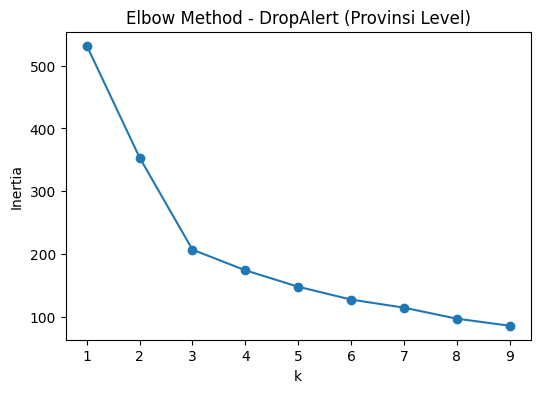

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 2. Menyiapkan Data untuk Clustering
# rata-rata per provinsi (menghilangkan efek tahun)
df_cluster = df_model.groupby('Provinsi')[features_cluster].mean().reset_index()

features_cluster = [
    'gabungan_pendudukmiskin',
    'TPT',
    'NEET_usiamuda',
    'tenagakerjaformal',

    'gabungan_HLS',
    'gabungan_RLS',

    'rasio_guru_SMA',
    'rasio_guru_SMK',
    'rasio_guru_SD',
    'rasio_guru_SMP',

    'rasio_sekolah_SMA',
    'rasio_sekolah_SMK',
    'rasio_sekolah_SD',
    'rasio_sekolah_SMP'
]
X = df_cluster[features_cluster]

# 3. Scaling (WAJIB untuk K-Means)
scaler = StandardScaler()
Z = scaler.fit_transform(X)

# 4. Elbow Method
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Z)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method - DropAlert (Provinsi Level)")
plt.show()

Dari grafik elbow method, titik “siku” (elbow) terlihat paling jelas di **k = 3**.

* Penurunan inertia sangat tajam dari k=1 sampai k=3.
* Setelah k = 3, penurunannya mulai melandai sehingga penambahan cluster tidak memberi peningkatan signifikan.

Jadi, jumlah cluster yang disarankan untuk K-Means pada grafik tersebut adalah **3 cluster**.


In [46]:
# 5. Silhouette Score
sil_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Z)
    sil_scores.append(silhouette_score(Z, labels))

for k, s in zip(range(2, 10), sil_scores):
    print(f"k={k}, silhouette={s:.4f}")

k=2, silhouette=0.2941
k=3, silhouette=0.3985
k=4, silhouette=0.2736
k=5, silhouette=0.2490
k=6, silhouette=0.2793
k=7, silhouette=0.2753
k=8, silhouette=0.2869
k=9, silhouette=0.2938


Hasil silhouette score menunjukkan bahwa nilai tertinggi terdapat pada **k = 3 (0.3985)**. Dengan demikian, jumlah cluster yang paling optimal secara relatif adalah **3 cluster**, karena memberikan pemisahan terbaik dibandingkan konfigurasi lainnya.

Namun, nilai silhouette secara keseluruhan masih berada pada rentang **rendah–sedang (±0.25–0.40)**. Hal ini menunjukkan bahwa:

* Pemisahan antar cluster belum terlalu tegas
* Karakteristik antar provinsi relatif saling beririsan
* Struktur data lebih bersifat **kontinu (gradual)** dibandingkan tersegmentasi jelas

Dengan kata lain, data pendidikan dan sosial-ekonomi antar provinsi cenderung membentuk spektrum bertahap, bukan kelompok yang benar-benar terpisah secara alami.


In [47]:
# 6. Model K-Means Final
optimal_k = 3  # sesuaikan dengan hasil elbow + silhouette

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(Z)

# 7. Profil Cluster
cluster_profile = df_cluster.groupby('cluster')[features_cluster].mean()
cluster_profile

,gabungan_pendudukmiskin,TPT,NEET_usiamuda,tenagakerjaformal,gabungan_HLS,gabungan_RLS,rasio_guru_SMA,rasio_guru_SMK,rasio_guru_SD,rasio_guru_SMP,rasio_sekolah_SMA,rasio_sekolah_SMK,rasio_sekolah_SD,rasio_sekolah_SMP
cluster,,,,,,,,,,,,,,
0,7.300263,13.425447,19.749895,45.742947,13.346053,9.127632,0.065037,0.067816,0.067698,0.069664,0.002700,0.002654,0.005904,0.004124
1,13.583250,4.456125,12.274000,12.265500,4.447250,3.947250,0.065902,0.083464,0.044501,0.064762,0.003547,0.004025,0.005588,0.004860
2,11.745000,13.080167,22.941067,34.696533,13.004200,8.576133,0.082131,0.101973,0.087641,0.105639,0.003549,0.004374,0.008373,0.006920



=== Cluster 0 (19 provinsi) ===
- BALI
- BANTEN
- DI YOGYAKARTA
- DKI JAKARTA
- JAWA BARAT
- JAWA TENGAH
- JAWA TIMUR
- KALIMANTAN BARAT
- KALIMANTAN SELATAN
- KALIMANTAN TIMUR
- KALIMANTAN UTARA
- KEP. BANGKA BELITUNG
- KEP. RIAU
- LAMPUNG
- RIAU
- SULAWESI SELATAN
- SUMATERA BARAT
- SUMATERA SELATAN
- SUMATERA UTARA

=== Cluster 1 (4 provinsi) ===
- PAPUA
- PAPUA PEGUNUNGAN
- PAPUA SELATAN
- PAPUA TENGAH

=== Cluster 2 (15 provinsi) ===
- ACEH
- BENGKULU
- GORONTALO
- JAMBI
- KALIMANTAN TENGAH
- MALUKU
- MALUKU UTARA
- NUSA TENGGARA BARAT
- NUSA TENGGARA TIMUR
- PAPUA BARAT
- PAPUA BARAT DAYA
- SULAWESI BARAT
- SULAWESI TENGAH
- SULAWESI TENGGARA
- SULAWESI UTARA


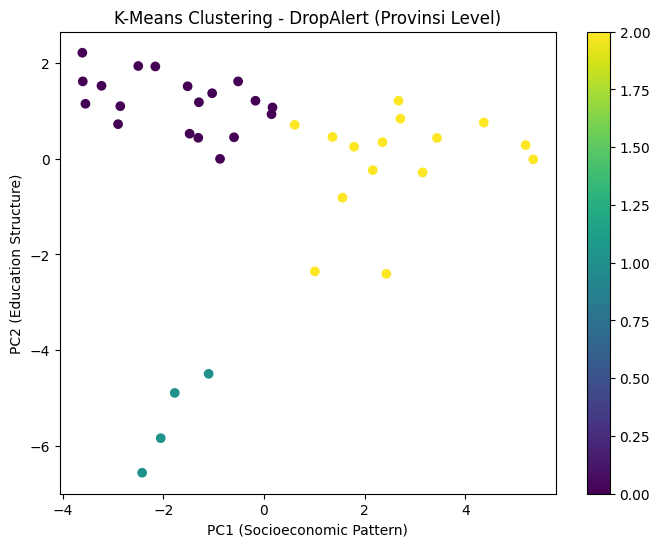

In [49]:
# 8. Daftar Provinsi per Cluster
clusters = df_cluster.groupby('cluster')['Provinsi'].apply(list)
for c, prov in clusters.items():
    print(f"\n=== Cluster {c} ({len(prov)} provinsi) ===")
    for p in prov:
        print("-", p)

# 9. Visualisasi PCA (2D Cluster Plot)
pca = PCA(n_components=2)
pc = pca.fit_transform(Z)

df_cluster['PC1'] = pc[:, 0]
df_cluster['PC2'] = pc[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(df_cluster['PC1'], df_cluster['PC2'],
            c=df_cluster['cluster'], cmap='viridis')

plt.xlabel("PC1 (Socioeconomic Pattern)")
plt.ylabel("PC2 (Education Structure)")
plt.title("K-Means Clustering - DropAlert (Provinsi Level)")
plt.colorbar()
plt.show()

In [50]:
df_cluster.to_csv("dropalert_cluster_provinsi.csv", index=False)

### Interpretasi Profil Cluster K-Means

Hasil clustering membentuk **3 kelompok utama provinsi** dengan karakteristik sosial-ekonomi dan pendidikan yang berbeda cukup jelas.

### **Cluster 0 (19 provinsi) — Wilayah dengan NEET tinggi & tenaga kerja formal tinggi**

Cluster ini didominasi provinsi besar di Jawa dan sebagian Sumatera/Kalimantan.

Ciri utama:

* Kemiskinan relatif **rendah (7.30%)**
* NEET **tinggi (19.75%)**
* TPT **tinggi (13.42%)**
* Tenaga kerja formal **paling tinggi (45.74%)**
* Pendidikan (HLS & RLS) **menengah ke atas**
* Rasio guru dan sekolah relatif **rendah–sedang**

Interpretasi:
Kelompok ini mencerminkan wilayah dengan struktur ekonomi lebih formal, namun masih menghadapi masalah transisi pendidikan-ke-kerja (NEET dan pengangguran cukup tinggi). Ini menunjukkan adanya mismatch antara output pendidikan dan pasar kerja.

### **Cluster 1 (4 provinsi) — Wilayah sangat rentan (Papua cluster)**

Ciri utama:

* Kemiskinan **tertinggi (13.58%)**
* NEET **rendah–sedang (12.27%)**
* TPT **sangat rendah (4.45%)**
* Tenaga kerja formal **sangat rendah (12.26%)**
* HLS & RLS **terendah (4.44 & 3.95 tahun)**
* Rasio guru & sekolah **cukup rendah**

Interpretasi:
Cluster ini menunjukkan kondisi **kerentanan struktural pendidikan paling serius**, ditandai rendahnya capaian pendidikan dan minimnya tenaga kerja formal. Meski TPT rendah, ini lebih mencerminkan keterbatasan partisipasi pasar kerja formal, bukan kondisi yang benar-benar sehat.

### **Cluster 2 (15 provinsi) — Wilayah menengah dengan tekanan pendidikan tinggi**

Ciri utama:

* Kemiskinan **sedang (11.74%)**
* TPT **tinggi (13.08%)**
* NEET **tinggi (22.94%) — tertinggi**
* Tenaga kerja formal **menengah (34.69%)**
* HLS & RLS **menengah**
* Rasio guru & sekolah **relatif paling tinggi**

Interpretasi:
Kelompok ini menunjukkan wilayah dengan **tekanan sosial-ekonomi dan pendidikan yang cukup tinggi**, terutama pada indikator NEET. Walaupun infrastruktur pendidikan relatif lebih baik, outputnya belum sepenuhnya terserap ke sistem kerja atau pendidikan lanjutan.

### **Kesimpulan Umum**

* Cluster 1 → **paling rentan secara struktural (Papua region)**
* Cluster 2 → **tekanan tinggi pada NEET & pengangguran (middle vulnerability)**
* Cluster 0 → **ekonomi lebih formal tapi masalah transisi pendidikan–kerja**

Secara keseluruhan, hasil clustering menunjukkan bahwa perbedaan antar provinsi tidak hanya ditentukan oleh tingkat kemiskinan, tetapi juga oleh **interaksi antara pendidikan, NEET, dan struktur tenaga kerja formal**.

